In [11]:
import numpy as np
from scipy.stats import poisson
import math
import os
from collections import Counter
import re
from functools import lru_cache
import json
from datetime import datetime, timedelta
from collections import OrderedDict
start_date = datetime(2025, 3, 7)
end_date = datetime(2025, 3, 13)

TIME_RANGE = [(start_date + timedelta(days=i)).strftime("%Y-%m-%d") for i in range((end_date - start_date).days + 1)]

RE_HASHTAG = re.compile("#\w*", flags=re.UNICODE)
RE_URL = r'https?:\/\/(www\.)?[-a-zA-Z0-9@:%._\+~#=]{1,256}\.[a-zA-Z0-9()]{1,6}\b([-a-zA-Z0-9()@:%_\+.~#?&\/\/=]*)'
RE_SPECIAL_CHARS = r'[\.\,\!\@\#\$\%\^\&\*\(\)\=\|\"\'\;\:\‘\’\“\”\‼️\-\[\]\{\}\?\<\>\…\/\\\~\+]'

def add_date(count_date: dict, date: str):
    if date not in count_date:
        count_date[date] = 1
    else:
        count_date[date] += 1

def strip_hashtag(text: str) -> str:
    return RE_HASHTAG.sub(r'', text)

def strip_url(text: str) -> str:
    return re.sub(RE_URL, '', text)

def strip_special_chars(text: str) -> str:
    return re.sub(RE_SPECIAL_CHARS, '', text)

def clean_text(text: str) -> str:
    processed_text = text.strip().replace("\n", " ").replace("\t", " ")
    processed_text = strip_hashtag(processed_text)
    processed_text = strip_url(processed_text)
    processed_text = strip_special_chars(processed_text)
    return processed_text

@lru_cache(maxsize=10000)
def get_cosine(text1: str, text2: str):
    vec1 = Counter(text1.split())
    vec2 = Counter(text2.split())

    intersection = set(vec1.keys()) & set(vec2.keys())
    numerator = sum(vec1[x] * vec2[x] for x in intersection)

    sum1 = sum(vec1[x] ** 2 for x in vec1)
    sum2 = sum(vec2[x] ** 2 for x in vec2)
    denominator = math.sqrt(sum1) * math.sqrt(sum2)

    return 0.0 if denominator == 0 else numerator / denominator

def entities_similar(e1: str, e2: str, score=0.75):
    cleaned_text_1 = clean_text(e1)
    cleaned_text_2 = clean_text(e2)

    if cleaned_text_1 == cleaned_text_2:
        return True
    
    if ((cleaned_text_1 in cleaned_text_2 and len(cleaned_text_1.split()) >= 2 and len(cleaned_text_2.split()) > len(cleaned_text_1.split())) or 
        (cleaned_text_2 in cleaned_text_1 and len(cleaned_text_2.split()) >= 2 and len(cleaned_text_1.split()) > len(cleaned_text_2.split()))):
        return True
    
    if get_cosine(cleaned_text_1, cleaned_text_2) >= score:
        return True
    
    return False

def entities_sets_similar(set1: set, set2: set, score=0.6) -> bool:
    count_to_match = 2

    if len(set1.intersection(set2)) >= count_to_match:
        return True
    
    count_similar = 0
    for e1 in set1:
        for e2 in set2:
            if entities_similar(e1, e2, score=score):
                count_similar += 1
                # return True
    
    return count_similar >= count_to_match

def detect_trends_sliding(counts, z_threshold=2, cusum_multiplier=3, window_size=2):
    """
    Detect trends using a sliding 2-day baseline window.
    
    Args:
        counts: List of 7 daily event counts.
        z_threshold: Z-score threshold for spikes (default=2).
        cusum_multiplier: Multiplier for CUSUM threshold (default=3).
        window_size: Number of days for sliding baseline (default=2).
    
    Returns:
        dict: Trend scores and flags for each day (Days 3–7).
    """
    counts = np.array(counts)
    results = []
    
    for t in range(window_size, len(counts)):
        # Sliding baseline (previous 2 days)
        baseline = counts[t-window_size:t]
        mu = np.mean(baseline)
        
        # --- Handle near-zero baselines ---
        if mu < 1:
            min_abs_increase = 1
            cusum_threshold = 1
        else:
            min_abs_increase = max(2, 0.5 * mu)
            cusum_threshold = cusum_multiplier * max(np.std(baseline, ddof=0), 1.0)
        
        # --- Poisson Significance ---
        poisson_p = 1 - poisson.cdf(counts[t] - 1, mu) if mu > 0 else 0
        
        # --- Z-score with σ flooring ---
        sigma = max(np.std(baseline, ddof=0), 1.0)
        z_score = (counts[t] - mu) / sigma
        
        # --- CUSUM (single-step deviation) ---
        delta = 0.5 * mu
        S = max(0, counts[t] - (mu + delta))
        
        # --- Trend Logic ---
        is_spike = (z_score > z_threshold) or (counts[t] >= mu + min_abs_increase + 0.1)
        is_trend = ((S >= cusum_threshold) or (poisson_p < 0.01)) and is_spike == True
        # print(is_spike, is_trend)
        
        trend_score = z_score + S / (cusum_threshold + 1e-6)
        
        results.append({
            'day': t + 1,  # Convert to 1-based index
            'trend_score': trend_score,
            'trend_confirmed': is_trend,
            'poisson_p': poisson_p,
            'z_score': z_score,
            'cusum': S,
            'baseline_mean': mu,
            'baseline_std': sigma
        })
    
    trending_day = None
    max_trending_score = -1

    for item in results:
        if item['trend_confirmed'] == True:
            if item['trend_score'] > max_trending_score:
                trending_day = item['day']
                max_trending_score = item['trend_score']

    return trending_day, max_trending_score

def detect_trends(file_path: str):
    with open(file_path) as f:
        groups = json.load(f)

    for gr in groups:
        gr['urls'] = set([e['url'] for e in gr['entities']])
        gr['entities_texts'] = {text for e in gr['entities'] for text in e['texts']}

    all_groups = set(range(len(groups)))

    groups_clustering = []
    for index_i in range(len(groups)):
        for index_j in range(index_i + 1, len(groups)):
            mutual_urls = groups[index_i]['urls'].intersection(groups[index_j]['urls'])
            if len(mutual_urls) > 1:
                
                cluster_found = False
                for cluster in groups_clustering:
                    if (index_i in cluster) or (index_j in cluster):
                        entities_matched = True
                        current_entities = groups[index_j]['entities_texts'] if index_i in cluster else groups[index_i]['entities_texts']
                        for child_group in cluster:
                            if not entities_sets_similar(current_entities, groups[child_group]['entities_texts']):
                                entities_matched = False
                                cluster_found = True
                                break
                        
                        if entities_matched:
                            cluster.add(index_i)
                            cluster.add(index_j)
                            cluster_found = True
                            break
                
                if not cluster_found and entities_sets_similar(groups[index_j]['entities_texts'], groups[index_i]['entities_texts']):
                    groups_clustering.append({index_i, index_j})

    merged_groups = []
    for cluster in groups_clustering:
        init_group = cluster.pop()
        new_group = groups[init_group].copy()
        if type(new_group["triggers"]) == str:
            new_group["triggers"] = {new_group["triggers"]}

        for related_group in cluster:
            new_group["entities"] += groups[related_group]["entities"]
            new_group["triggers"].add(groups[related_group]["triggers"])
            if related_group in all_groups:
                all_groups.remove(related_group)

        if "urls" in new_group:
            new_group.pop("urls")
        if "entities_texts" in new_group:
            new_group.pop("entities_texts")

        merged_groups.append(new_group)

        if init_group in all_groups:
            all_groups.remove(init_group)

    for gr in all_groups:
        groups[gr].pop("urls")
        groups[gr].pop("entities_texts")
        merged_groups.append(groups[gr])

    trends = []
    for gr in merged_groups:
        set_sentence = set()
        set_url = set()
        count_date = OrderedDict((date, 0) for date in TIME_RANGE)
        for e in gr['entities']:
            if e['url'] not in set_url:
                set_url.add(e['url'])
                set_sentence.add(e['sentence'])
                add_date(count_date, e['date'])

            elif e['sentence'] in set_sentence:
                set_url.add(e['url'])
                set_sentence.add(e['sentence'])
                add_date(count_date, e['date'])

        trends.append({
            "trend": detect_trends_sliding(list(dict(count_date).values())),
            "count": dict(count_date),
            "data": gr
        })

    trends = sorted(trends, key=lambda x: x["trend"][-1], reverse=True)
    filtered = []
    for t in trends:
        if t['trend'][0] == None:
            continue
        filtered.append(t)

    return filtered

directory_path = '/home/mhtuan/work/mbf/fine_grained_v3'
files = [f"{directory_path}/{f}" for f in os.listdir(directory_path)]
trend_count_dict = dict()
for f in files:
    trigger_type = f[(f.rfind('_') + 1):-5]
    detected_trends = detect_trends(f)
    trend_count_dict[trigger_type] = len(detected_trends)

In [21]:
trend_count_dict

{'Start-position': 46,
 'End-position': 46,
 'Transfer-money': 191,
 'Appeal': 4,
 'Be-born': 36,
 'Demonstrate': 7,
 'Marry': 7,
 'Start-org': 78,
 'Trial-hearing': 18,
 'End-org': 17,
 'Arquit': 1,
 'Attack': 313,
 'Transport': 479,
 'Charge-indict': 19,
 'Merge-org': 33,
 'Arrest-jail': 105,
 'Transfer-ownership': 261,
 'Convict': 6,
 'Sentence': 14,
 'Injure': 48,
 'Release-parole': 15,
 'Execute': 4,
 'Pardon': 11,
 'Sue': 4,
 'Fine': 29,
 'Elect': 37,
 'Meet': 610,
 'Extradite': 0,
 'Declare-bankruptcy': 2,
 'Divorce': 1,
 'Nominate': 41,
 'Die': 144,
 'Phone-write': 43}

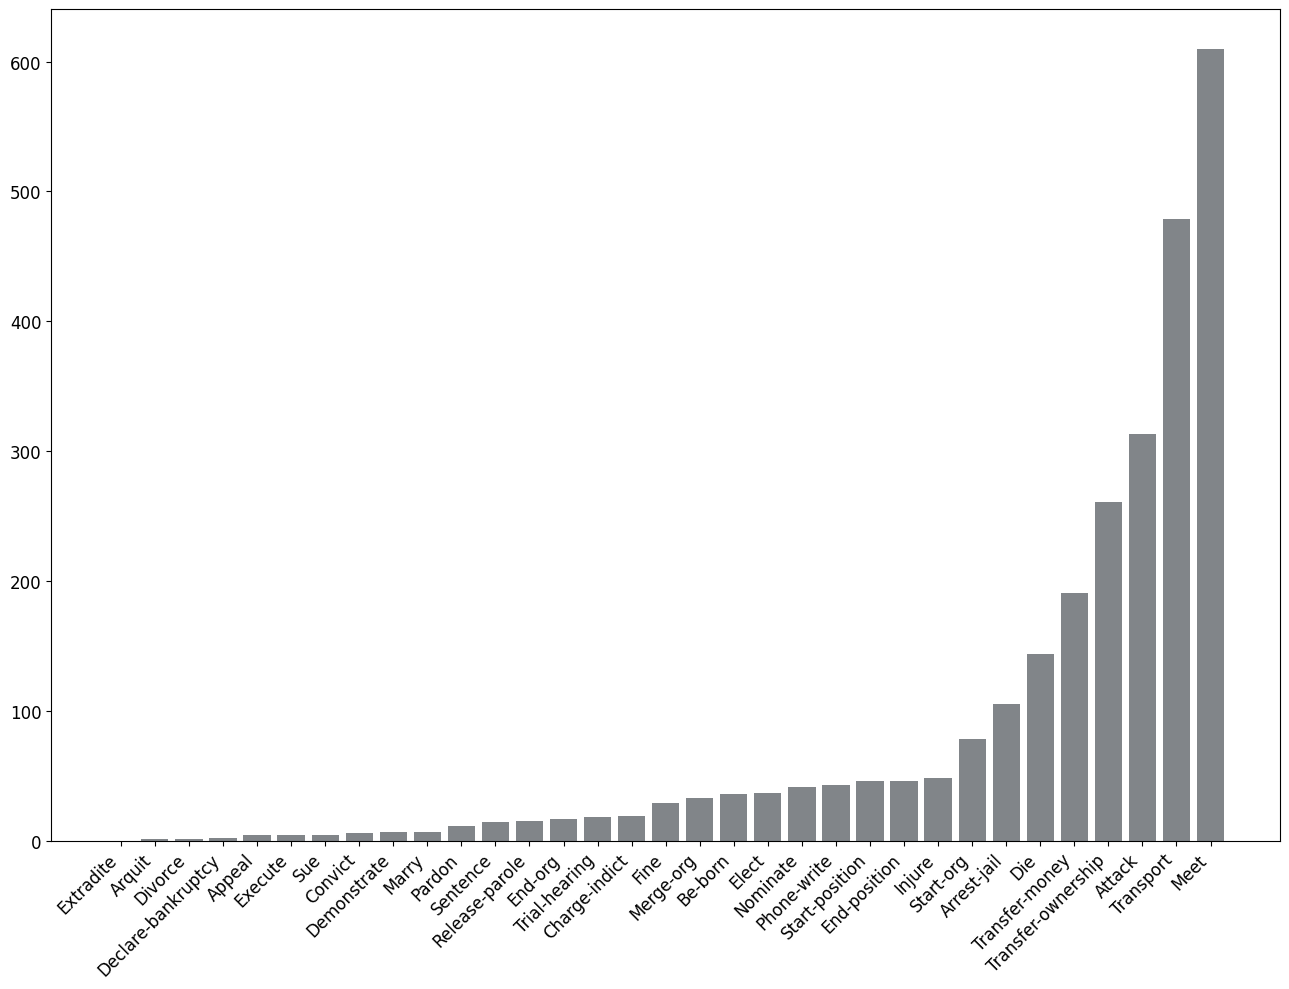

In [20]:
import matplotlib.pyplot as plt

# Sample dictionary
data = dict(sorted(trend_count_dict.items(), key=lambda item: item[1]))
labels = list(data.keys())
values = list(data.values())

# Create a wider column graph
plt.figure(figsize=(13, 10))  # Adjust the width and height as needed
colors = ['#818589' for value in values]

# Create the bar chart with specified colors
plt.bar(labels, values, color=colors)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)  # Change fontsize here
plt.yticks(fontsize=12)  # Change fontsize for y-axis labels

# Show the plot
plt.tight_layout()  # Adjust layout to fit labels
plt.show()